---

[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppestana-supervisor/PDI_python/blob/main/topico3/Topico3.ipynb)

> **Nota importante**
>
> Este notebook é carregado diretamente a partir do repositório oficial no GitHub e é apenas para **leitura**.  
> As alterações **não ficam guardadas**.
>
> Para guardar uma versão pessoal:
> - No Colab, ir a **Ficheiro → Guardar uma cópia no Drive**.  
> - A cópia ficará disponível em `O meu Drive / Colab Notebooks`.
>
> Para colaboração:
> - Abrir a versão pessoal no Google Drive.  
> - Clicar em **Partilhar** → **Qualquer pessoa com o link pode editar** (ou adicionar os colegas manualmente).  
> - A partir daí, todos podem editar em tempo real, como num Google Docs.
>
> Para guardar resultados (imagens, ficheiros, etc.) no  Drive:
> ```python
> from google.colab import drive
> drive.mount('/content/drive')
> ```
> Depois gravar, por exemplo, em:
> ```python
> img.save('/content/drive/MyDrive/PDI_outputs/resultado.png')
> ```

---

In [ ]:
### !!! Executar esta célula primeiro, se dentro do Colab
# Quando dentro do Colab, clonar o repositório completo para garantir acesso à pasta de imagens
!git clone https://github.com/ppestana-supervisor/PDI_python.git
%cd PDI_python/topico5

# 01. Transfer Learning para Classificação de Imagens com MobileNetV2


Neste notebook, vamos explorar o conceito de *transfer learning* aplicado a imagens, utilizando um modelo pré‑treinado (MobileNetV2) para classificar imagens de flores. A técnica de transfer learning permite reutilizar redes já treinadas em grandes conjuntos de dados (como o ImageNet) como ponto de partida para novas tarefas, reduzindo o tempo de treino e melhorando a generalização quando temos poucos dados.

Usaremos o dataset Flowers102, que contém 102 categorias de flores, e treinaremos apenas a parte final do modelo para mapear as características extraídas para as respetivas classes. No final, vamos avaliar a performance do modelo e visualizar algumas previsões diretamente sobre as imagens.


## 1. Importação de bibliotecas e carregamento dos dados

Nesta célula, carregamos o conjunto de dados **Oxford Flowers102**, composto por 102 categorias de flores, e aplicamos transformações básicas de pré-processamento:

- Redimensionamento das imagens para 160×160 px  
- Conversão para tensores PyTorch  
- Normalização para o intervalo `[-1, 1]`  

Em seguida, criamos dois *DataLoaders*:
- `train_loader` — usado para alimentar o modelo durante o treino, com *batches* de 32 imagens e baralhamento ativado.  
- `test_loader` — usado para avaliação, sem baralhar os dados.

Estas estruturas permitem que o modelo leia e processe eficientemente as imagens em pequenos grupos, otimizando o desempenho durante o treino e teste.

**Nota Pedagógica:** O conjunto Flowers102 inclui originalmente partições de treino, validação e teste.
No entanto, a implementação em torchvision junta o treino e a validação originais num único split (train).
Para um treino rigoroso, recomenda-se dividir manualmente este conjunto em treino (≈80%) e validação (≈20%), reservando o split test apenas para a avaliação final do modelo.

In [1]:
import torch
import torchvision
import torch.nn as nn
import torchvision.models as models
from torchvision.models import MobileNet_V2_Weights
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision.transforms.functional as F
import torch.optim as optim

import matplotlib.pyplot as plt
import numpy as np
import random
from tqdm import tqdm

transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

dataset = datasets.Flowers102(root='data', split='train', download=True, transform=transform)
test_dataset = datasets.Flowers102(root='data', split='test', download=True, transform=transform)

train_loader = DataLoader(dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)


## 2. Visualização de algumas imagens

Esta célula serve para confirmar que o *DataLoader* está a funcionar corretamente e para observar exemplos reais do conjunto de treino.

1. É obtido um lote de imagens (`images, labels`) a partir do `train_loader`.  
2. As primeiras 8 imagens são organizadas numa grelha de 4×2 com a função `torchvision.utils.make_grid`.  
3. A grelha é normalizada para facilitar a visualização e mostrada com o Matplotlib.

O resultado é uma amostra representativa das flores do conjunto **Flowers102**, útil para verificar dimensões, cores e coerência do pré-processamento.

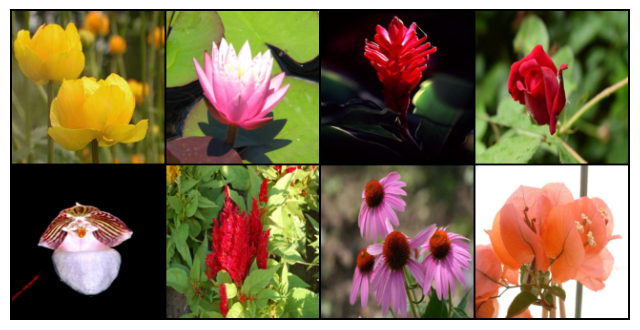

In [2]:
images, labels = next(iter(train_loader))
img_grid = torchvision.utils.make_grid(images[:8], nrow=4, normalize=True)
plt.figure(figsize=(8,8))
plt.imshow(img_grid.permute(1, 2, 0))
plt.axis('off')
plt.show()

## 3. Carregamento do MobileNetV2 pré-treinado

Nesta célula é configurado o modelo base que servirá de ponto de partida para a tarefa de classificação das flores.

1. **Seleção do modelo base:** é utilizada a arquitetura *MobileNetV2* pré-treinada no ImageNet, disponível na biblioteca `torchvision.models`. Este modelo é leve e eficiente, adequado para treino rápido e para dispositivos com recursos limitados.  
2. **Congelamento das camadas de extração de características:** todos os parâmetros das camadas convolucionais (`base_model.features`) são congelados (`requires_grad = False`), de modo que os seus pesos não sejam alterados durante o treino. Assim, o modelo mantém o conhecimento genérico previamente adquirido sobre padrões visuais.  
3. **Definição da nova camada de saída:** como o conjunto *Flowers102* tem 102 classes, substitui-se o classificador original por uma nova camada `nn.Linear` com 102 neurónios de saída.  
   - É adicionada também uma camada `Dropout` para reduzir o risco de *overfitting*.  
4. **Envio do modelo para o dispositivo apropriado:** o modelo é movido para GPU, se disponível (`cuda`), ou para CPU, caso contrário.

**Nota pedagógica:** este tipo de adaptação é um exemplo clássico de *transfer learning*, onde se reaproveita a capacidade de representação de um modelo pré-treinado, ajustando apenas a parte final para uma nova tarefa específica.

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = MobileNet_V2_Weights.DEFAULT
base_model = models.mobilenet_v2(weights=weights)

# Congelar as camadas convolucionais
for param in base_model.features.parameters():
    param.requires_grad = False

# Substituir a camada de classificação para 102 classes
num_classes = 102
base_model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(base_model.last_channel, num_classes)
)

model = base_model.to(device)

## 4. Treino do modelo

Esta célula implementa o ciclo de treino do modelo, responsável por ajustar os pesos da nova camada de classificação para a tarefa das flores.

1. **Definição do otimizador e da função de perda:**  
   - `criterion = nn.CrossEntropyLoss()` define a função de custo apropriada para problemas de classificação multiclasse.  
   - `optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)` utiliza o otimizador *Adam* para atualizar apenas os parâmetros do classificador (as camadas convolucionais permanecem congeladas).  

2. **Configuração do treino:**  
   - O modelo é colocado em modo de treino com `model.train()`, o que ativa camadas como *Dropout*.  
   - Define-se um total de 5 épocas, significando que o modelo passará cinco vezes por todo o conjunto de treino.

3. **Laço principal de treino:**  
   - Para cada *batch* de imagens e rótulos, os dados são enviados para o dispositivo (`CPU` ou `GPU`).  
   - O gradiente anterior é limpo (`optimizer.zero_grad()`), e as imagens passam pelo modelo (`outputs = model(images)`).  
   - A perda é calculada (`loss = criterion(outputs, labels)`), propagada para trás (`loss.backward()`), e os pesos do classificador são atualizados (`optimizer.step()`).  
   - A perda média é acumulada e atualizada na *progress bar*.

4. **Monitorização:**  
   - A barra de progresso `tqdm` mostra o andamento de cada época e o valor instantâneo da perda.  
   - No final de cada época, é impresso o valor médio da perda sobre todos os lotes.

**Nota pedagógica:** durante o *transfer learning*, apenas as camadas de saída são ajustadas. O objetivo é especializar o modelo num novo domínio (flores) sem destruir o conhecimento adquirido anteriormente (características visuais gerais do ImageNet).

A *CrossEntropyLoss* é a escolha mais comum para tarefas de classificação, mas existem alternativas:  
- *Label Smoothing* pode ser usada para reduzir a confiança excessiva do modelo nas previsões, ajudando na generalização;  
- *Focal Loss* é útil em conjuntos de dados desbalanceados, pois dá mais peso às classes sub-representadas;  
- *Mean Squared Error* é, em princípio, aplicável, mas raramente usada para classificação, pois não modela bem probabilidades.  

Quanto ao número de épocas, não há um valor fixo — depende do tamanho do conjunto de dados, da taxa de aprendizagem e da complexidade do modelo.  
Geralmente, o número ideal é determinado empiricamente através da monitorização da perda e da métrica de validação:  
- Se a perda de treino continua a descer, mas a de validação começa a subir, é sinal de *overfitting* e deve parar-se o treino.  
- Ferramentas como *early stopping* automatizam esta decisão, interrompendo o treino quando o desempenho deixa de melhorar.

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

epochs = 5
model.train()
for epoch in range(epochs):
    running_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Época {epoch+1}", leave=False)
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())
    print(f"Época {epoch+1}, Loss médio (treino): {running_loss / len(train_loader):.4f}")

Época 1, Loss médio (treino): 4.3413


Época 2, Loss médio (treino): 2.8320


Época 3, Loss médio (treino): 1.8751


Época 4, Loss médio (treino): 1.2784


Época 5, Loss médio (treino): 0.9070


## 5. Avaliação do modelo no conjunto de teste e previsões

Esta célula avalia o desempenho final do modelo sobre o conjunto de teste, medindo a sua capacidade de generalização em dados nunca vistos durante o treino.

1. **Modo de avaliação:**  
   O modelo é colocado em modo de avaliação com `model.eval()`.  
   Isto desativa camadas como *Dropout* e *Batch Normalization*, garantindo resultados consistentes.  
   Além disso, o bloco `torch.no_grad()` impede o cálculo de gradientes, tornando a inferência mais rápida e poupando memória.

2. **Processamento do conjunto de teste:**  
   As imagens e rótulos são lidos lote a lote (`test_loader`), enviados para o dispositivo (`CPU` ou `GPU`), e processados pelo modelo (`outputs = model(images)`).

3. **Cálculo da predição:**  
   - `torch.max(outputs.data, 1)` devolve o índice da classe com maior probabilidade para cada imagem.  
   - Compara-se este valor com o rótulo verdadeiro (`predicted == labels`) para contar o número de acertos.

4. **Cálculo da taxa de acerto:**  
   A métrica usada é a **Taxa de acerto** (ou *accuracy*), calculada como:
   $$
    \text{Taxa de Acerto} = \frac{\text{Número de acertos}}{\text{Total de amostras}} \times 100
    $$
   A barra de progresso `tqdm` mostra a accuracy acumulada à medida que as previsões são realizadas, e no final é impressa a taxa global sobre todo o conjunto de teste.

**Nota pedagógica:**  
A accuracy é uma métrica intuitiva e útil em conjuntos equilibrados, mas pode ser enganadora quando há classes desbalanceadas.  
Em contextos mais exigentes, podem usar-se métricas complementares, como *Precision*, *Recall*, *F1-score* ou *Matriz de Confusão*, para obter uma visão mais detalhada do comportamento do modelo em cada classe.

In [5]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    progress_bar = tqdm(test_loader, desc="Avaliação", leave=False)
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        accuracy_so_far = 100 * correct / total
        progress_bar.set_postfix(accuracy=f"{accuracy_so_far:.2f}%")

accuracy = 100 * correct / total
print(f"Taxa de Acerto (Accuracy) final no conjunto de teste: {accuracy:.2f}%")

Taxa de Acerto (Accuracy) final no conjunto de teste: 72.99%


## 6. Visualização de previsões

Esta célula mostra exemplos concretos de imagens do conjunto de teste juntamente com as classes previstas pelo modelo e as classes verdadeiras.  
O objetivo é avaliar visualmente a qualidade das previsões e perceber em que tipos de imagem o modelo acerta ou falha.

1. **Preparação dos dados:**  
   - O modelo é colocado em modo de avaliação (`model.eval()`), e um lote de imagens é obtido do `test_loader`.  
   - As imagens são movidas para o dispositivo apropriado (`CPU` ou `GPU`).

2. **Geração das previsões:**  
   - Com `torch.no_grad()`, obtêm-se as previsões sem calcular gradientes.  
   - `torch.max(outputs, 1)` devolve, para cada imagem, o índice da classe com maior probabilidade.  
   - Estes índices são guardados como rótulos previstos (`predicted_labels`).

3. **Seleção e reconstrução das imagens:**  
   - São escolhidos aleatoriamente oito índices dentro do lote (`random.sample(...)`).  
   - As imagens correspondentes são convertidas novamente para formato *PIL* para visualização, aplicando o processo inverso da normalização usada no carregamento (`img * 0.5 + 0.5`).

4. **Apresentação dos resultados:**  
   - As oito imagens são dispostas numa grelha 2×4 com o Matplotlib.  
   - Cada uma mostra o rótulo previsto e o rótulo verdadeiro (`Previsto: … | Verdadeiro: …`).

**Nota pedagógica:**  
Esta visualização qualitativa ajuda a compreender o comportamento do modelo para além dos números globais.  
É frequente que o modelo acerte em classes visualmente distintas, mas confunda categorias semelhantes (por exemplo, flores com cores ou formatos parecidos).  
Para análise mais profunda, pode ser útil mapear os índices de classes para nomes legíveis e destacar visualmente as previsões corretas e incorretas com cores diferentes nos títulos.

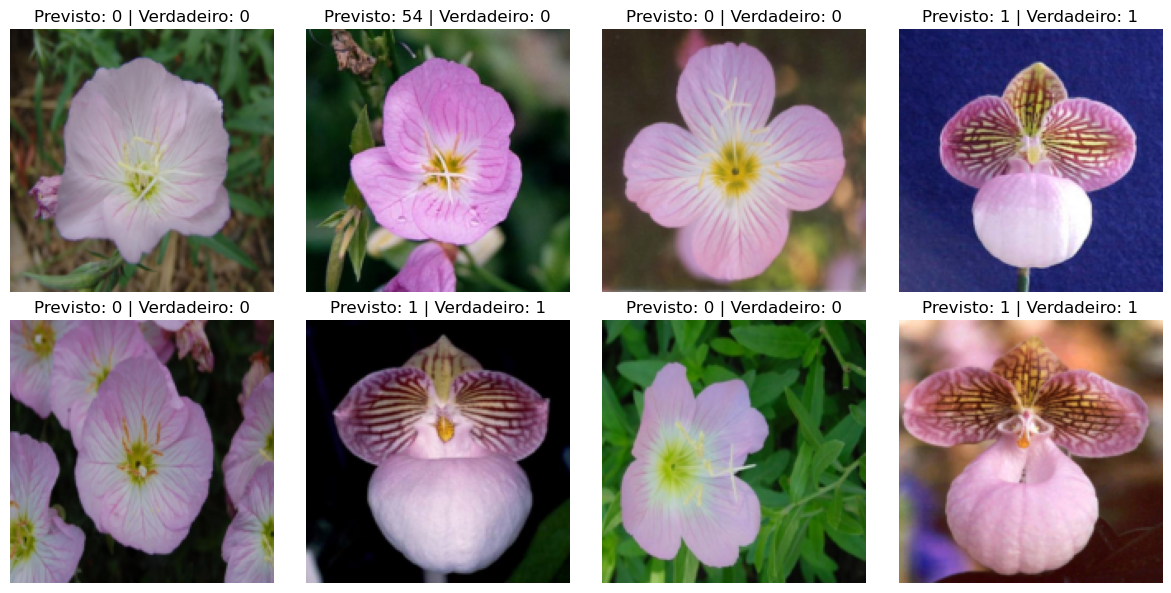

In [6]:
model.eval()
images, true_labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    _, predicted_labels = torch.max(outputs, 1)

# Gerar 8 índices aleatórios dentro do batch
indices = random.sample(range(len(images)), 8)

plt.figure(figsize=(12, 6))
for i, idx in enumerate(indices):
    img = images[idx].cpu()
    img = F.to_pil_image((img * 0.5 + 0.5).clamp(0, 1))  # Unnormalize
    pred = predicted_labels[idx].item()
    true = true_labels[idx] if isinstance(true_labels[idx], int) else true_labels[idx].item()

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Previsto: {pred} | Verdadeiro: {true}")
    plt.axis('off')

plt.tight_layout()
plt.show()